# DS4400 Homework 4 - Isabella Caruz

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.naive_bayes import CategoricalNB
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    zero_one_loss,
    roc_curve,
    precision_score,
    recall_score
)

## Problem 1: Decision Trees (25 points)

In [ ]:
data = pd.read_csv("spambase.data", header=None)

X = data.iloc[:, :-1]  
y = data.iloc[:, -1]    

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,        
    random_state=42
)

print(f"Training: {len(X_train)} samples")
print(f"Test: {len(X_test)} samples")

Training: 3680 samples
Test: 921 samples


In [7]:
dt_entropy = DecisionTreeClassifier(
    criterion='entropy',
    random_state=42
)

dt_entropy.fit(X_train, y_train)

# Predictions
y_train_pred = dt_entropy.predict(X_train)
y_test_pred = dt_entropy.predict(X_test)

# Probabilities (for AUC)
y_train_prob = dt_entropy.predict_proba(X_train)[:, 1]
y_test_prob = dt_entropy.predict_proba(X_test)[:, 1]

# Metrics
train_error = zero_one_loss(y_train, y_train_pred)
test_error = zero_one_loss(y_test, y_test_pred)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

train_f1 = f1_score(y_train, y_train_pred)
test_f1 = f1_score(y_test, y_test_pred)

train_auc = roc_auc_score(y_train, y_train_prob)
test_auc = roc_auc_score(y_test, y_test_prob)

print(f"Training Error:   {train_error:.4f}")
print(f"Testing Error:    {test_error:.4f}")
print(f"Training Accuracy:{train_acc:.4f}")
print(f"Testing Accuracy: {test_acc:.4f}")
print(f"Training F1:      {train_f1:.4f}")
print(f"Testing F1:       {test_f1:.4f}")
print(f"Training AUC:     {train_auc:.4f}")
print(f"Testing AUC:      {test_auc:.4f}")

Training Error:   0.0003
Testing Error:    0.0803
Training Accuracy:0.9997
Testing Accuracy: 0.9197
Training F1:      0.9997
Testing F1:       0.8984
Training AUC:     1.0000
Testing AUC:      0.9164


In [9]:
dt_gini = DecisionTreeClassifier(
    criterion='gini',
    random_state=42
)

dt_gini.fit(X_train, y_train)

y_train_pred = dt_gini.predict(X_train)
y_test_pred = dt_gini.predict(X_test)

y_train_prob = dt_gini.predict_proba(X_train)[:, 1]
y_test_prob = dt_gini.predict_proba(X_test)[:, 1]

train_error = zero_one_loss(y_train, y_train_pred)
test_error = zero_one_loss(y_test, y_test_pred)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

train_f1 = f1_score(y_train, y_train_pred)
test_f1 = f1_score(y_test, y_test_pred)

train_auc = roc_auc_score(y_train, y_train_prob)
test_auc = roc_auc_score(y_test, y_test_prob)

print(f"Training Error:   {train_error:.4f}")
print(f"Testing Error:    {test_error:.4f}")
print(f"Training Accuracy:{train_acc:.4f}")
print(f"Testing Accuracy: {test_acc:.4f}")
print(f"Training F1:      {train_f1:.4f}")
print(f"Testing F1:       {test_f1:.4f}")
print(f"Training AUC:     {train_auc:.4f}")
print(f"Testing AUC:      {test_auc:.4f}")

Training Error:   0.0003
Testing Error:    0.0890
Training Accuracy:0.9997
Testing Accuracy: 0.9110
Training F1:      0.9997
Testing F1:       0.8877
Training AUC:     1.0000
Testing AUC:      0.9078


In [10]:
depths = list(range(1, 31))
results = []

for d in depths:
    tree = DecisionTreeClassifier(
        criterion='entropy',
        max_depth=d,
        random_state=42
    )
    
    tree.fit(X_train, y_train)
    
    train_error = zero_one_loss(y_train, tree.predict(X_train))
    test_error = zero_one_loss(y_test, tree.predict(X_test))
    
    results.append({
        'depth': d,
        'train_error': train_error,
        'test_error': test_error
    })
    
    print(f"depth={d:2d}: Train Error={train_error:.4f}, Test Error={test_error:.4f}")

depth= 1: Train Error=0.2011, Test Error=0.2269
depth= 2: Train Error=0.1312, Test Error=0.1520
depth= 3: Train Error=0.1236, Test Error=0.1455
depth= 4: Train Error=0.0889, Test Error=0.1183
depth= 5: Train Error=0.0772, Test Error=0.1021
depth= 6: Train Error=0.0707, Test Error=0.0966
depth= 7: Train Error=0.0693, Test Error=0.0945
depth= 8: Train Error=0.0484, Test Error=0.0760
depth= 9: Train Error=0.0348, Test Error=0.0771
depth=10: Train Error=0.0266, Test Error=0.0760
depth=11: Train Error=0.0236, Test Error=0.0695
depth=12: Train Error=0.0185, Test Error=0.0738
depth=13: Train Error=0.0144, Test Error=0.0771
depth=14: Train Error=0.0125, Test Error=0.0738
depth=15: Train Error=0.0098, Test Error=0.0717
depth=16: Train Error=0.0087, Test Error=0.0760
depth=17: Train Error=0.0079, Test Error=0.0782
depth=18: Train Error=0.0060, Test Error=0.0749
depth=19: Train Error=0.0038, Test Error=0.0771
depth=20: Train Error=0.0049, Test Error=0.0793
depth=21: Train Error=0.0014, Test Error

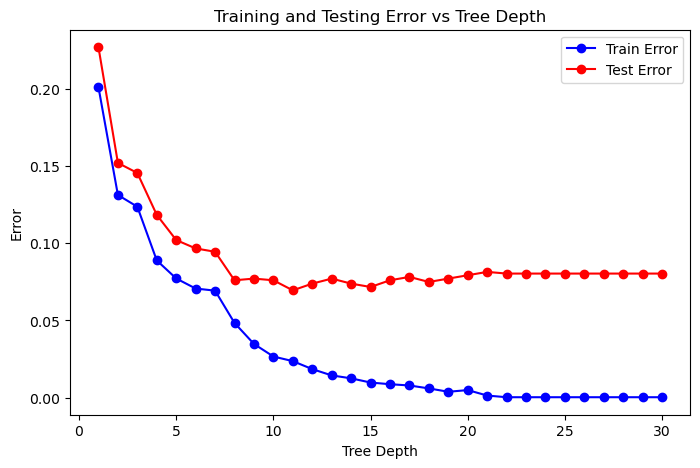

In [11]:
df = pd.DataFrame(results)

plt.figure(figsize=(8,5))
plt.plot(df['depth'], df['train_error'], 'b-o', label='Train Error')
plt.plot(df['depth'], df['test_error'], 'r-o', label='Test Error')
plt.xlabel("Tree Depth")
plt.ylabel("Error")
plt.title("Training and Testing Error vs Tree Depth")
plt.legend()
plt.show()

In [12]:
best_depth = df.loc[df['test_error'].idxmin(), 'depth']
print("Best depth:", best_depth)

Best depth: 11


## Problem 2: Random Forest Ensemble (25 points)

In [15]:

n_trees = [10, 50, 100, 500]
results = []

for T in n_trees:
    rf = RandomForestClassifier(
        n_estimators=T,
        random_state=42
    )
    
    rf.fit(X_train, y_train)
    
    y_train_pred = rf.predict(X_train)
    y_test_pred = rf.predict(X_test)
    
    y_train_prob = rf.predict_proba(X_train)[:, 1]
    y_test_prob = rf.predict_proba(X_test)[:, 1]
    
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    
    train_f1 = f1_score(y_train, y_train_pred)
    test_f1 = f1_score(y_test, y_test_pred)
    
    train_auc = roc_auc_score(y_train, y_train_prob)
    test_auc = roc_auc_score(y_test, y_test_prob)
    
    results.append({
        'T': T,
        'train_acc': train_acc,
        'test_acc': test_acc,
        'train_f1': train_f1,
        'test_f1': test_f1,
        'train_auc': train_auc,
        'test_auc': test_auc
    })
    
    print(f"T={T:3d} | Train Acc={train_acc:.4f}, Test Acc={test_acc:.4f}, Test AUC={test_auc:.4f}")


df_rf = pd.DataFrame(results)
df_rf

T= 10 | Train Acc=0.9954, Test Acc=0.9425, Test AUC=0.9797
T= 50 | Train Acc=0.9997, Test Acc=0.9425, Test AUC=0.9827
T=100 | Train Acc=0.9997, Test Acc=0.9457, Test AUC=0.9834
T=500 | Train Acc=0.9997, Test Acc=0.9446, Test AUC=0.9836


,T,train_acc,test_acc,train_f1,test_f1,train_auc,test_auc
0,10,0.995380,0.942454,0.994112,0.925035,0.999947,0.979731
1,50,0.999728,0.942454,0.999655,0.925247,1.000000,0.982676
2,100,0.999728,0.945711,0.999655,0.929775,1.000000,0.983385
3,500,0.999728,0.944625,0.999655,0.928270,1.000000,0.983575


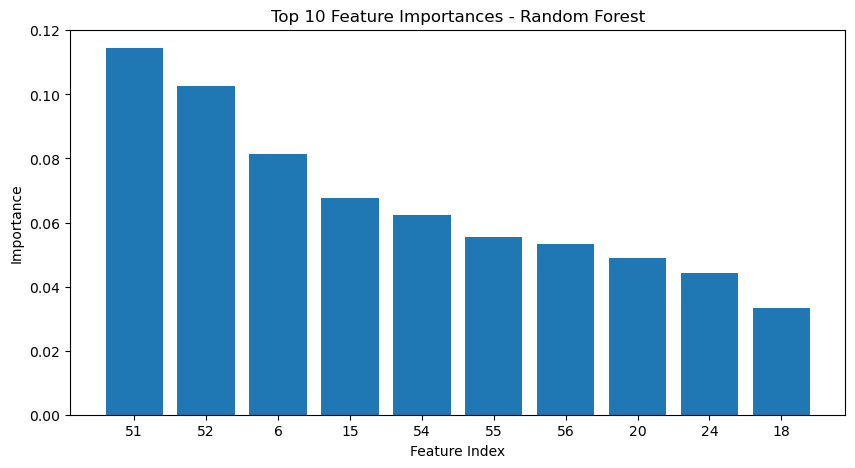

In [17]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,5))
plt.title("Top 10 Feature Importances - Random Forest")
plt.bar(range(10), importances[indices][:10])
plt.xticks(range(10), indices[:10])
plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.show()

In [21]:
n_estimators = [10, 50, 100, 500]
results = []

for T in n_estimators:
    ada = AdaBoostClassifier(
        n_estimators=T,
        random_state=42
    )
    
    ada.fit(X_train, y_train)
    
    y_train_pred = ada.predict(X_train)
    y_test_pred = ada.predict(X_test)
    
    y_train_prob = ada.predict_proba(X_train)[:, 1]
    y_test_prob = ada.predict_proba(X_test)[:, 1]
    
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    
    train_f1 = f1_score(y_train, y_train_pred)
    test_f1 = f1_score(y_test, y_test_pred)
    
    train_auc = roc_auc_score(y_train, y_train_prob)
    test_auc = roc_auc_score(y_test, y_test_prob)
    
    results.append({
        'T': T,
        'train_acc': train_acc,
        'test_acc': test_acc,
        'train_f1': train_f1,
        'test_f1': test_f1,
        'train_auc': train_auc,
        'test_auc': test_auc
    })
    
    print(f"T={T:3d} | Train Acc={train_acc:.4f}, Test Acc={test_acc:.4f}, Test AUC={test_auc:.4f}")

df_ada = pd.DataFrame(results)
df_ada = df_ada.round(4)
df_ada

T= 10 | Train Acc=0.9212, Test Acc=0.9131, Test AUC=0.9668
T= 50 | Train Acc=0.9535, Test Acc=0.9240, Test AUC=0.9736
T=100 | Train Acc=0.9628, Test Acc=0.9316, Test AUC=0.9729
T=500 | Train Acc=0.9883, Test Acc=0.9403, Test AUC=0.9677


,T,train_acc,test_acc,train_f1,test_f1,train_auc,test_auc
0,10,0.9212,0.9131,0.8971,0.8867,0.9745,0.9668
1,50,0.9535,0.9240,0.9405,0.9033,0.9909,0.9736
2,100,0.9628,0.9316,0.9527,0.9124,0.9947,0.9729
3,500,0.9883,0.9403,0.9851,0.9243,0.9996,0.9677


In [23]:
n_estimators = [10, 50, 100, 500]
results = []

for T in n_estimators:
    ada = AdaBoostClassifier(
        n_estimators=T,
        random_state=42
    )
    
    ada.fit(X_train, y_train)
    
    y_train_pred = ada.predict(X_train)
    y_test_pred = ada.predict(X_test)
    
    y_train_prob = ada.predict_proba(X_train)[:, 1]
    y_test_prob = ada.predict_proba(X_test)[:, 1]
    
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    
    train_f1 = f1_score(y_train, y_train_pred)
    test_f1 = f1_score(y_test, y_test_pred)
    
    train_auc = roc_auc_score(y_train, y_train_prob)
    test_auc = roc_auc_score(y_test, y_test_prob)
    
    results.append({
        'T': T,
        'train_acc': train_acc,
        'test_acc': test_acc,
        'train_f1': train_f1,
        'test_f1': test_f1,
        'train_auc': train_auc,
        'test_auc': test_auc
    })
    
    print(f"T={T:3d} | Train Acc={train_acc:.4f}, Test Acc={test_acc:.4f}, Test AUC={test_auc:.4f}")

df_ada = pd.DataFrame(results)[
    ['T', 'train_acc', 'test_acc', 'train_f1', 'test_f1', 'train_auc', 'test_auc']
].round(4)

df_ada

T= 10 | Train Acc=0.9212, Test Acc=0.9131, Test AUC=0.9668
T= 50 | Train Acc=0.9535, Test Acc=0.9240, Test AUC=0.9736
T=100 | Train Acc=0.9628, Test Acc=0.9316, Test AUC=0.9729
T=500 | Train Acc=0.9883, Test Acc=0.9403, Test AUC=0.9677


,T,train_acc,test_acc,train_f1,test_f1,train_auc,test_auc
0,10,0.9212,0.9131,0.8971,0.8867,0.9745,0.9668
1,50,0.9535,0.9240,0.9405,0.9033,0.9909,0.9736
2,100,0.9628,0.9316,0.9527,0.9124,0.9947,0.9729
3,500,0.9883,0.9403,0.9851,0.9243,0.9996,0.9677


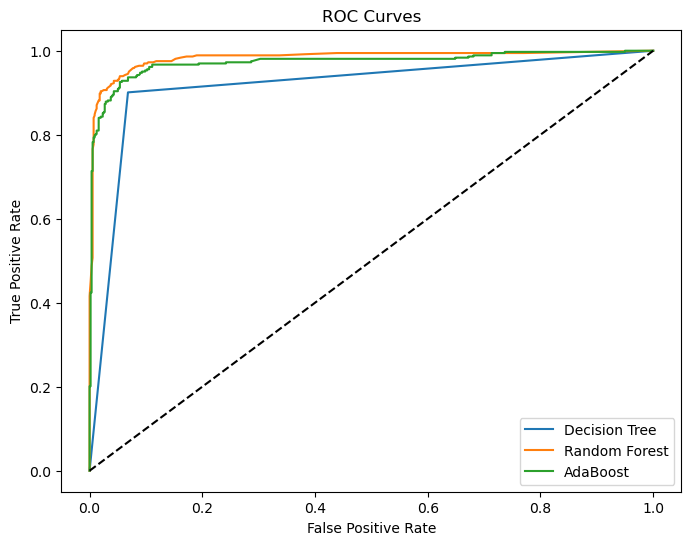

In [26]:
dt = DecisionTreeClassifier(criterion='entropy', random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
ada = AdaBoostClassifier(n_estimators=100, random_state=42)

dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
ada.fit(X_train, y_train)

dt_prob = dt.predict_proba(X_test)[:, 1]
rf_prob = rf.predict_proba(X_test)[:, 1]
ada_prob = ada.predict_proba(X_test)[:, 1]

dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
ada_fpr, ada_tpr, _ = roc_curve(y_test, ada_prob)

plt.figure(figsize=(8, 6))
plt.plot(dt_fpr, dt_tpr, label='Decision Tree')
plt.plot(rf_fpr, rf_tpr, label='Random Forest')
plt.plot(ada_fpr, ada_tpr, label='AdaBoost')
plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

## Problem 4: Naive Bayes classifier (25 points)

In [28]:
data = pd.read_csv("agaricus-lepiota.data", header=None)

y = data.iloc[:, 0]
X = data.iloc[:, 1:]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=42
)


In [29]:
priors = y_train.value_counts(normalize=True)

P_edible = priors['e']
P_poisonous = priors['p']

print("P(Edible):", P_edible)
print("P(Poisonous):", P_poisonous)

cond_probs = {}

classes = ['e', 'p']

for col in X_train.columns:
    cond_probs[col] = {}
    
    values = X_train[col].unique()
    
    for c in classes:
        cond_probs[col][c] = {}
        
        subset = X_train[y_train == c]
        total = len(subset)
        
        k = len(values) 
        
        for v in values:
            count = (subset[col] == v).sum()
            
            prob = (count + 1) / (total + k)
            
            cond_probs[col][c][v] = prob

P(Edible): 0.517971442639094
P(Poisonous): 0.48202855736090594


In [35]:
def predict_nb(X, priors, cond_probs):
    predictions = []
    probs = []
    
    for _, row in X.iterrows():
        log_prob_e = np.log(priors['e'])
        log_prob_p = np.log(priors['p'])
        
        for col in X.columns:
            val = row[col]
            
            log_prob_e += np.log(cond_probs[col]['e'].get(val, 1e-9))
            log_prob_p += np.log(cond_probs[col]['p'].get(val, 1e-9))
        
        max_log = max(log_prob_e, log_prob_p)
        prob_e = np.exp(log_prob_e - max_log)
        prob_p = np.exp(log_prob_p - max_log)
        
        total = prob_e + prob_p
        prob_e /= total
        prob_p /= total
        
        probs.append((prob_e, prob_p))
        
        if prob_e > prob_p:
            predictions.append('e')
        else:
            predictions.append('p')
    
    return predictions, probs

y_pred, y_probs = predict_nb(X_test, priors, cond_probs)

print("Sample Predictions:")
for i in range(5):
    print(f"Predicted: {y_pred[i]}, P(Edible)={y_probs[i][0]:.4f}, P(Poisonous)={y_probs[i][1]:.4f}")

Sample Predictions:
Predicted: e, P(Edible)=1.0000, P(Poisonous)=0.0000
Predicted: p, P(Edible)=0.0000, P(Poisonous)=1.0000
Predicted: e, P(Edible)=1.0000, P(Poisonous)=0.0000
Predicted: e, P(Edible)=0.9795, P(Poisonous)=0.0205
Predicted: p, P(Edible)=0.0000, P(Poisonous)=1.0000


In [40]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, pos_label='p')
rec = recall_score(y_test, y_pred, pos_label='p')
f1 = f1_score(y_test, y_pred, pos_label='p')

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")

Accuracy:  0.9527
Precision: 0.9911
Recall:    0.9101
F1 Score:  0.9489


In [44]:
encoder = OrdinalEncoder()
X_train_enc = encoder.fit_transform(X_train)
X_test_enc = encoder.transform(X_test)

nb = CategoricalNB()
nb.fit(X_train_enc, y_train)

y_pred_pkg = nb.predict(X_test_enc)

acc_pkg = accuracy_score(y_test, y_pred_pkg)
prec_pkg = precision_score(y_test, y_pred_pkg, pos_label='p')
rec_pkg = recall_score(y_test, y_pred_pkg, pos_label='p')
f1_pkg = f1_score(y_test, y_pred_pkg, pos_label='p')

print("Sklearn model:")
print(f"Accuracy:  {acc_pkg:.4f}")
print(f"Precision: {prec_pkg:.4f}")
print(f"Recall:    {rec_pkg:.4f}")
print(f"F1 Score:  {f1_pkg:.4f}")

Sklearn model:
Accuracy:  0.9527
Precision: 0.9911
Recall:    0.9101
F1 Score:  0.9489
